In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

In [2]:
df = pd.read_csv(
    "../data/processed/telco_segmented.csv"
)

df.head()

,CustomerID,City,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,...,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Revenue_Per_Month,Tenure_Group,Charge_Group,Cluster,Customer Segment
0,3668-QPYBK,Los Angeles,Male,No,No,No,2,Yes,No,DSL,...,Yes,1,86,3239,Competitor made better offer,36.050000,0-1 Year,Medium,2,At Risk Customers
1,9237-HQITU,Los Angeles,Female,No,No,Yes,2,Yes,No,Fiber optic,...,Yes,1,67,2701,Moved,50.550000,0-1 Year,High,2,At Risk Customers
2,9305-CDSKC,Los Angeles,Female,No,No,Yes,8,Yes,Yes,Fiber optic,...,Yes,1,86,5372,Moved,91.166667,0-1 Year,Very High,1,Loyal Customers
3,7892-POOKP,Los Angeles,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,...,Yes,1,84,5003,Moved,105.036207,2-4 Years,Very High,0,Champions
4,0280-XJGEX,Los Angeles,Male,No,No,Yes,49,Yes,Yes,Fiber optic,...,Yes,1,89,5340,Competitor had better devices,100.726000,4-6 Years,Very High,0,Champions


In [4]:
cols_to_drop = [

    "CustomerID",

    "Churn Label",
    "Churn Value",
    "Churn Score",
    "Churn Reason"

]

X = df.drop(
    columns=cols_to_drop,
    errors="ignore"
)

y = df["Churn Label"]

In [5]:
le = LabelEncoder()

y = le.fit_transform(y)

In [6]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

In [9]:
lr = LogisticRegression(
    max_iter=1000
)

X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(X_test)


c:\Users\Himit\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        lr_pred
    )
)

print(
    "F1:",
    f1_score(
        y_test,
        lr_pred
    )
)

Accuracy: 0.7991483321504613
F1: 0.5904486251808972


In [11]:
rf = RandomForestClassifier(

    n_estimators=300,

    random_state=42

)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

In [12]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.68      0.50      0.58       374

    accuracy                           0.80      1409
   macro avg       0.76      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [13]:
xgb = XGBClassifier(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=4,

    random_state=42

)

xgb.fit(
    X_train,
    y_train
)

xgb_pred = xgb.predict(X_test)

In [15]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        xgb_pred
    )
)

print(
    "Precision:",
    precision_score(
        y_test,
        xgb_pred
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        xgb_pred
    )
)

print(
    "F1:",
    f1_score(
        y_test,
        xgb_pred
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        xgb_pred
    )
)

Accuracy: 0.7998580553584103
Precision: 0.6503267973856209
Recall: 0.5320855614973262
F1: 0.5852941176470589
ROC-AUC: 0.7143519594926245


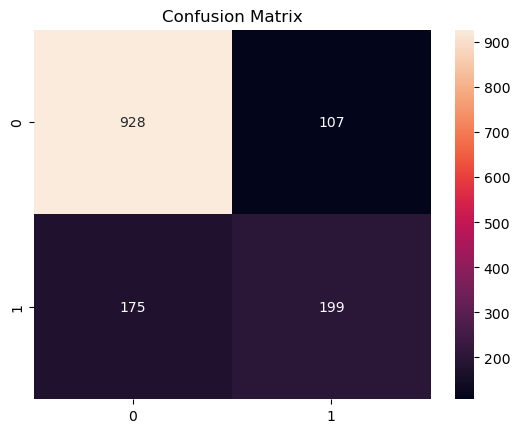

In [16]:
cm = confusion_matrix(
    y_test,
    xgb_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "Confusion Matrix"
)

plt.show()

In [17]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": xgb.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

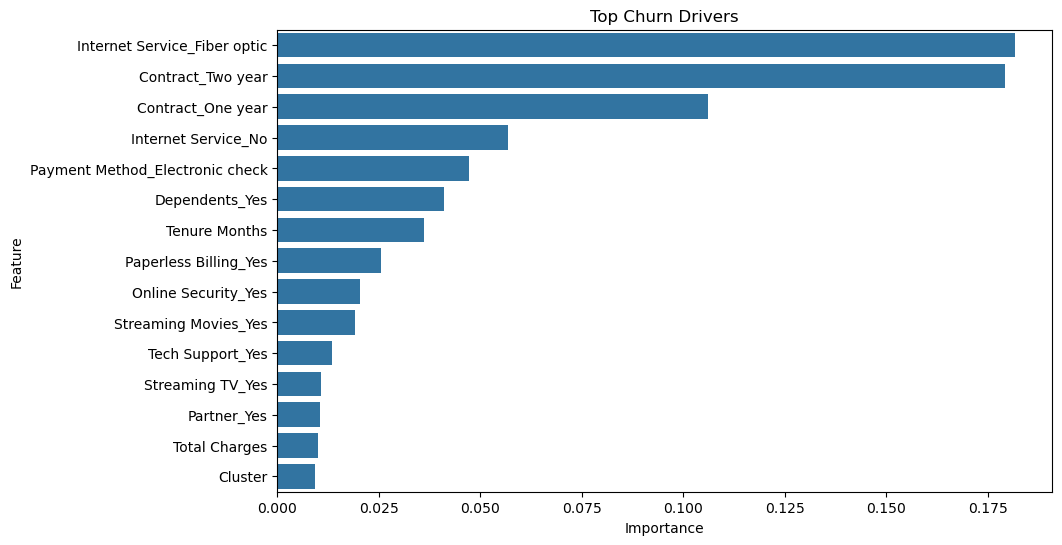

In [18]:
plt.figure(
    figsize=(10,6)
)

sns.barplot(

    data=importance.head(15),

    x="Importance",

    y="Feature"

)

plt.title(
    "Top Churn Drivers"
)

plt.show()

In [19]:
all_probs = xgb.predict_proba(
X
)[:,1]

df["Predicted_Churn_Probability"] = (
all_probs
)

high_risk_customers = df[
df[
"Predicted_Churn_Probability"
] >= 0.70
]

print(
high_risk_customers.shape
)

(635, 32)


In [20]:
high_risk_customers.to_csv(

"../data/processed/high_risk_customers.csv",

index=False)

In [21]:
import joblib

joblib.dump(

xgb,

"../model/xgb_model.pkl"

)

joblib.dump(

X.columns.tolist(),

"../model/model_columns.pkl"

)

joblib.dump(
    xgb,
    "../model/xgb_model.pkl"
)

joblib.dump(
    X.columns.tolist(),
    "../model/model_columns.pkl"
)

joblib.dump(
    le,
    "../model/target_encoder.pkl"
)

print(
    "Model Saved Successfully"
)

print(
"Model Saved Successfully"
)

Model Saved Successfully
Model Saved Successfully


In [22]:
print(X.shape)

(7043, 1170)


In [23]:
importance.head(15)

,Feature,Importance
1141,Internet Service_Fiber optic,0.181758
1156,Contract_Two year,0.179114
1155,Contract_One year,0.106154
1142,Internet Service_No,0.056790
1159,Payment Method_Electronic check,0.047317
1137,Dependents_Yes,0.041130
0,Tenure Months,0.036151
1157,Paperless Billing_Yes,0.025601
1144,Online Security_Yes,0.020458
1154,Streaming Movies_Yes,0.019165
